(ch:ml-iris)=
# 분류 입문: 붓꽃 품종 예측

이 장에서는 scikit-learn에 내장된 Iris 데이터셋을 이용하여 붓꽃 품종을 예측하는 분류 문제를 다룬다. 분류는 입력 특성을 바탕으로 여러 범주 중 하나를 예측하는 머신러닝 문제이다.

## 데이터셋

Iris 데이터셋은 세 종류의 붓꽃에 대한 측정값을 담고 있다.

- setosa
- versicolor
- virginica

입력 특성은 꽃받침과 꽃잎의 길이와 너비이다. 모든 특성이 수치형이고 결측치가 없기 때문에, 처음 분류 모델을 배우기에 적합하다.

필요한 라이브러리와 scikit-learn의 Iris 데이터셋을 불러온다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

sns.set_theme(style="whitegrid")

`load_iris(as_frame=True)`를 사용하면 데이터가 pandas 데이터프레임 형태로 제공되어 열 이름을 확인하기 쉽다.

In [2]:
iris = load_iris(as_frame=True)

X = iris.data
y = iris.target
target_names = iris.target_names

iris_df = X.copy()
iris_df["species"] = pd.Categorical.from_codes(y, target_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


데이터의 크기와 클래스별 개수를 확인한다.

In [3]:
iris_df.shape

(150, 5)

In [4]:
iris_df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

각 특성의 기본 통계량을 확인한다. Iris 데이터셋의 측정값 단위는 센티미터이다.

In [5]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 탐색적 데이터 분석

꽃잎 길이와 꽃잎 너비를 산점도로 그려 품종이 어떻게 구분되는지 살펴본다. 단순한 두 특성만으로도 `setosa`는 다른 품종과 뚜렷하게 구분되는 편이다.

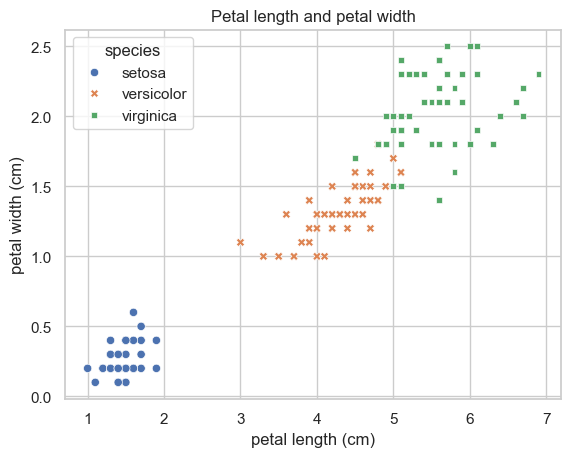

In [6]:
sns.scatterplot(
    data=iris_df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    style="species",
)
plt.title("Petal length and petal width")
plt.show()

상자그림으로 품종별 꽃잎 길이 분포를 비교한다.

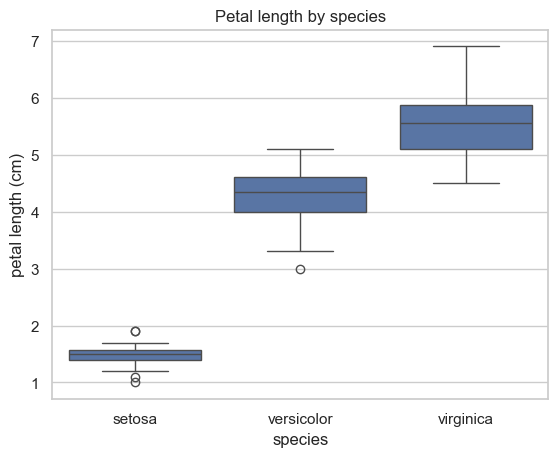

In [7]:
sns.boxplot(data=iris_df, x="species", y="petal length (cm)")
plt.title("Petal length by species")
plt.show()

## 두 특성만 사용한 분류

먼저 꽃잎 길이와 꽃잎 너비 두 특성만 사용한다. 적은 특성으로 모델을 만들면 분류 흐름을 단순하게 이해할 수 있고, 어떤 품종이 서로 헷갈리는지도 확인하기 쉽다.

In [8]:
selected_features = ["petal length (cm)", "petal width (cm)"]

X_selected = iris_df[selected_features]
y_species = iris_df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_species,
    test_size=0.3,
    random_state=42,
    stratify=y_species,
)

로지스틱 회귀 모델을 사용하기 전에 특성을 표준화한다. 표준화 기준은 훈련셋에서만 계산하고, 같은 기준을 테스트셋에 적용한다.

In [9]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=selected_features,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=selected_features,
    index=X_test.index,
)

In [10]:
iris_model = LogisticRegression(max_iter=1000)
iris_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

테스트셋에 대해 품종을 예측하고 정확도를 계산한다. 정확도는 전체 테스트 샘플 중 정답을 맞힌 비율이다.

In [11]:
y_pred = iris_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9111111111111111

혼동 행렬은 실제 품종과 예측 품종을 함께 보여준다. 대각선은 맞힌 개수이고, 대각선 밖의 값은 모델이 헷갈린 경우이다.

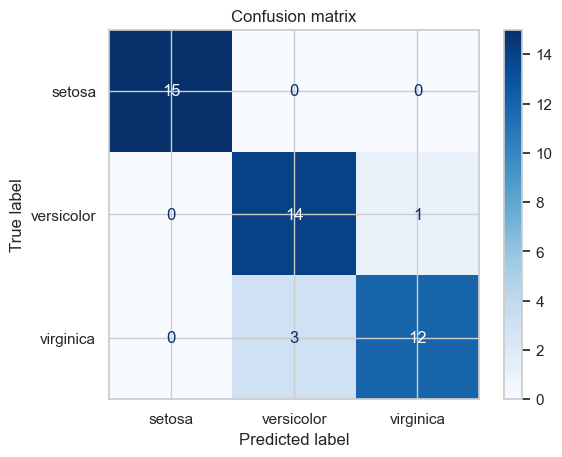

In [12]:
labels = iris_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

`classification_report()`는 클래스별 정밀도, 재현율, F1 점수를 보여준다. 다중 분류에서는 각 품종을 하나의 관심 클래스로 놓고 지표를 계산한다.

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## 전체 특성 사용하기

이번에는 꽃받침과 꽃잎의 네 가지 특성을 모두 사용한다. 특성을 더 많이 사용했을 때 성능이 어떻게 달라지는지 비교한다.

In [14]:
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X,
    y_species,
    test_size=0.3,
    random_state=42,
    stratify=y_species,
)

all_scaler = StandardScaler()
X_all_train_scaled = all_scaler.fit_transform(X_all_train)
X_all_test_scaled = all_scaler.transform(X_all_test)

iris_all_model = LogisticRegression(max_iter=1000)
iris_all_model.fit(X_all_train_scaled, y_all_train)

y_all_pred = iris_all_model.predict(X_all_test_scaled)
all_accuracy = accuracy_score(y_all_test, y_all_pred)

pd.DataFrame(
    {
        "model": ["petal features only", "all features"],
        "accuracy": [accuracy, all_accuracy],
    }
)

,model,accuracy
0,petal features only,0.911111
1,all features,0.911111


## 정리

이번 장에서는 Iris 데이터셋으로 분류 모델의 기본 흐름을 살펴보았다.

- 분류는 여러 범주 중 하나를 예측하는 문제이다.
- 훈련셋과 테스트셋을 나누어 모델의 일반화 성능을 확인한다.
- 정확도는 전체적으로 얼마나 맞혔는지를 보여준다.
- 혼동 행렬은 어떤 클래스를 어떤 클래스로 헷갈렸는지 보여준다.
- 정밀도와 재현율은 클래스별 성능을 더 자세히 해석하는 데 사용한다.

## 연습문제

**문제 1**

`sepal length (cm)`, `sepal width (cm)`만 사용하여 모델을 훈련해 보아라. 꽃잎 특성만 사용했을 때와 정확도가 어떻게 달라지는가?

**문제 2**

테스트셋 비율을 `0.2`, `0.4`로 바꾸어 보아라. 정확도와 혼동 행렬이 어떻게 달라지는가?

**문제 3**

혼동 행렬에서 가장 자주 헷갈리는 두 품종을 찾아보아라. 산점도에서 두 품종의 분포가 겹치는지 확인해 보아라.